# The degree normalisation exponent κ

In the GNAR(1, [1]) model with a normalisation exponent κ, the neighbour sum of node *i* is scaled by its degree to the power −κ:

$$X_{i,t} = \alpha_i X_{i,t-1} + \beta\, N_i^{-\kappa} \sum_{q \in \mathcal N(i)} X_{q,t-1} + \varepsilon_{i,t}.$$

κ = 1 is the standard GNAR neighbour average and κ = 0 means no normalisation. This notebook simulates the model on a small graph with heterogeneous degrees, estimates κ by profile likelihood, plots the profile and tests κ = 1.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from gnar import GNAR, simulate_gnar1, stationary_params, fit_gnar1, plot_profile, asymptotic_cov, variance_bounds
from gnar.utils.simulating import row_sum_bound, spectral_radius

## A graph with heterogeneous degrees

κ is identified only when the degrees differ: on a regular graph only β N^(−κ) is identified. Here a hub of degree 6 is joined to a triangle, a path and some leaves, so degrees range from 1 to 6.

degrees: [6 3 3 3 2 1 1 2 2 2 2 1]


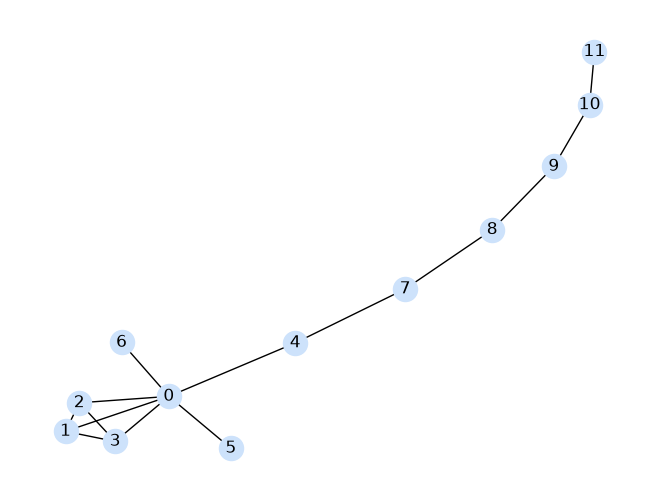

In [2]:
G = nx.Graph()
G.add_edges_from([(0, q) for q in range(1, 7)])               # hub 0 with six neighbours
G.add_edges_from([(1, 2), (2, 3), (3, 1)])                     # a triangle on 1, 2, 3
G.add_edges_from([(4, 7), (7, 8), (8, 9), (9, 10), (10, 11)])  # a path from node 4
A = nx.to_numpy_array(G, nodelist=range(12))
degrees = A.sum(axis=0)
print("degrees:", degrees.astype(int))
nx.draw(G, with_labels=True, node_color="#cde2fb")

## Parameters and simulation

`stationary_params` sets β so that the most heavily weighted node has total network weight *b*: $|\beta| = b / \max_i N_i^{1-\kappa}$. With $\max_i |\alpha_i| + b < 1$ the row-sum bound $\rho = \max_i(|\alpha_i| + |\beta| N_i^{1-\kappa})$ is below 1, so the process is stationary. `simulate_gnar1` starts from the stationary distribution, $X_0 \sim N(0, \Gamma^{(0)})$.

In [3]:
rng = np.random.default_rng(2026)
kappa_true = 0.5
alpha = rng.uniform(0.1, 0.4, 12)
beta = stationary_params(A, kappa_true, b=0.4, alpha=alpha)
print(f"beta = {beta:.4f}, rho = {row_sum_bound(A, alpha, beta, kappa_true):.3f}, "
      f"spectral radius = {spectral_radius(A, alpha, beta, kappa_true):.3f}")

X = simulate_gnar1(A, alpha, beta, kappa_true, n=3000, rng=rng)
X.shape

beta = 0.1633, rho = 0.621, spectral radius = 0.546


(3000, 12)

## Fitting

`fit_gnar1` estimates κ by profile likelihood when `kappa=None`: for each κ the αs and β have a closed form, so the profile costs O(N) per point. The data were simulated with mean zero, so the mean is not removed (`demean=False`).

In [4]:
fit = fit_gnar1(A, X, demean=False)
print(fit)

Kappa-normalised GNAR(1, [1]) fit: d = 12 nodes, T = 3000 time points, n = 35988 observations
kappa estimated in [0, 1.5]
sigma^2 = 0.998982 (estimated), RSS = 35937.4, loglik = -51039.4

           estimate         se     lower    upper   method       note
alpha[1]   0.133341  0.0176099 0.0988262 0.167856     wald           
alpha[2]   0.286648  0.0170886  0.253155 0.320141     wald           
alpha[3]   0.240926  0.0174723  0.206681 0.275171     wald           
alpha[4]   0.184127  0.0173436  0.150134  0.21812     wald           
alpha[5]   0.199228  0.0175389  0.164852 0.233604     wald           
alpha[6]   0.325261  0.0168251  0.292284 0.358237     wald           
alpha[7]   0.345517  0.0170619  0.312076 0.378957     wald           
alpha[8]   0.142837  0.0177446  0.108059 0.177616     wald           
alpha[9]   0.280408  0.0174514  0.246204 0.314613     wald           
alpha[10]  0.196339  0.0174724  0.162094 0.230584     wald           
alpha[11]  0.353078  0.0169629  0.319831 0

## The profile deviance

The deviance $\mathrm{dev}(\kappa) = n \log(\mathrm{RSS}(\kappa) / \mathrm{RSS}(\hat\kappa))$ crosses the χ²₁ cutoff at the ends of the profile-likelihood interval. The dashed curve is the Wald approximation $(\kappa - \hat\kappa)^2 / \mathrm{SE}(\hat\kappa)^2$; the two agree closely here, a sign that κ is well identified.

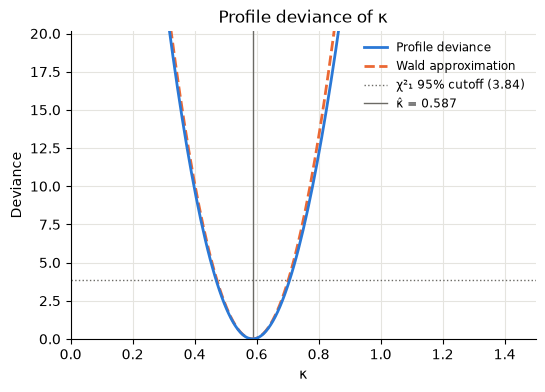

In [5]:
ax = plot_profile(fit)
ax.set_title("Profile deviance of κ")
plt.show()

## Inference

The standard errors come from the full Jacobian at $\hat\theta$, so they account for estimating κ. `test_kappa` tests κ = 1 (the standard GNAR normalisation) with both the Wald and the likelihood-ratio statistic. `beta_at` reports β at a reference degree, by default the geometric-mean degree. β̂ and κ̂ are strongly correlated; β̂₀ is exactly uncorrelated with κ̂ at the reference degree `beta_at("decorrelated")`, and nearly so at the geometric mean when κ̂ is close to 1/2, as here.

In [6]:
fit.summary()

,estimate,se,lower,upper,method,note
alpha[1],0.133341,0.017610,0.098826,0.167856,wald,
alpha[2],0.286648,0.017089,0.253155,0.320141,wald,
alpha[3],0.240926,0.017472,0.206681,0.275171,wald,
alpha[4],0.184127,0.017344,0.150134,0.218120,wald,
alpha[5],0.199228,0.017539,0.164852,0.233604,wald,
alpha[6],0.325261,0.016825,0.292284,0.358237,wald,
alpha[7],0.345517,0.017062,0.312076,0.378957,wald,
alpha[8],0.142837,0.017745,0.108059,0.177616,wald,
alpha[9],0.280408,0.017451,0.246204,0.314613,wald,
alpha[10],0.196339,0.017472,0.162094,0.230584,wald,


In [7]:
print("test of kappa = 1:", fit.test_kappa(1.0))
ref = fit.beta_at()
print("beta at the geometric-mean degree:", ref)
print("beta at the decorrelating degree:", fit.beta_at("decorrelated"))

# Correlations with kappa_hat, from the covariance of (beta_hat, kappa_hat) and the delta method for beta_0
V = fit.cov[-2:, -2:]
g = ref["N0"] ** -fit.kappa * np.array([1.0, -fit.beta * np.log(ref["N0"])])
print(f"corr(beta_hat, kappa_hat)   = {V[0, 1] / np.sqrt(V[0, 0] * V[1, 1]):.3f}")
print(f"corr(beta_0_hat, kappa_hat) = {g @ V[:, 1] / (ref['se'] * np.sqrt(V[1, 1])):.3f}")

test of kappa = 1: {'k0': 1.0, 'z': -7.0495151334388675, 'p_value': 1.7954230782753753e-12, 'lr': 43.24325562188546, 'lr_p_value': 4.834010931667348e-11}
beta at the geometric-mean degree: {'N0': 2.0396489026555056, 'beta_0': 0.11437550566338166, 'se': 0.0034523488875467063}
beta at the decorrelating degree: {'N0': 1.9933641987981074, 'beta_0': 0.1159271567004782, 'se': 0.003495710841479383}
corr(beta_hat, kappa_hat)   = 0.801
corr(beta_0_hat, kappa_hat) = -0.045


## Comparison with the theory

`asymptotic_cov` gives the exact asymptotic covariance from the true parameters and the graph alone, and `variance_bounds` the degree-based bounds on it.

In [8]:
n = X.shape[0]
asym = asymptotic_cov(A, alpha, beta, kappa_true, n=n)
bounds = variance_bounds(A, alpha, beta, kappa_true, n=n)
print(f"SE(kappa_hat): estimated {fit.se[-1]:.4f}, asymptotic {np.sqrt(asym[-1, -1]):.4f}")
print(f"bounds on SE(kappa_hat): [{np.sqrt(bounds['kappa']['lower']):.4f}, {np.sqrt(bounds['kappa']['upper']):.4f}] "
      f"(lower bound from rho only: {np.sqrt(bounds['kappa']['lower_rho']):.4f})")

SE(kappa_hat): estimated 0.0586, asymptotic 0.0577
bounds on SE(kappa_hat): [0.0359, 0.0631] (lower bound from rho only: 0.0314)


## Using the fit as a GNAR model

`GNAR(..., kappa=None)` estimates κ in the same way and keeps the full fit in `kappa_fit`; forecasts, simulation and the VAR form then use the estimated κ.

In [9]:
model = GNAR(A, p=1, s=np.array([1]), ts=X, kappa=None, demean=False)
print(repr(model))
model.predict(h=3)

GNAR(model_type="standard", net_type="unweighted", p=1, s=[1], d=12, kappa=0.58705, fitted=True)


array([[-0.09849704,  0.01533735,  0.20233256,  0.14674865, -0.25709748,
        -0.36559113, -0.15031721, -0.1968466 , -0.06942395,  0.16437892,
         0.39802855, -0.1628151 ],
       [-0.0379381 ,  0.02724805,  0.05454615,  0.03788817, -0.08539259,
        -0.13603151, -0.06905619, -0.06589595, -0.02322361,  0.07029393,
         0.1407159 ,  0.00877726],
       [-0.01542746,  0.01278029,  0.0156219 ,  0.01097562, -0.0290263 ,
        -0.05083946, -0.03045383, -0.02197942, -0.00600324,  0.02739543,
         0.05883226,  0.02771305]])